In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('../original_datasets/maintenance_history.csv')

print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 2074 entries, 0 to 2073
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   work_order_id     2074 non-null   str    
 1   vehicle_id        2074 non-null   str    
 2   service_date      2074 non-null   str    
 3   service_type      2074 non-null   str    
 4   parts_replaced    1486 non-null   str    
 5   labour_hours      2021 non-null   str    
 6   cost_inr          2074 non-null   str    
 7   downtime_hours    2074 non-null   float64
 8   failure_reported  1647 non-null   str    
 9   technician_id     2074 non-null   str    
dtypes: float64(1), str(9)
memory usage: 162.2 KB
None
       downtime_hours
count      2074.00000
mean         47.81866
std          27.38753
min           1.00000
25%          24.30000
50%          47.60000
75%          71.07500
max          96.00000
  work_order_id vehicle_id         service_date        service_type  \
0     WO-000001 

In [3]:
print(df.duplicated().sum())

60


In [4]:
df=df.drop_duplicates()

In [5]:
print(df.isna().sum())

work_order_id         0
vehicle_id            0
service_date          0
service_type          0
parts_replaced      574
labour_hours         51
cost_inr              0
downtime_hours        0
failure_reported    412
technician_id         0
dtype: int64


In [8]:
# Clean cost_inr (remove 'INR ', commas, etc.)
df['cost_inr'] = df['cost_inr'].astype(str).str.replace('INR', '', regex=False).str.replace(',', '', regex=False).str.strip()
df['cost_inr'] = pd.to_numeric(df['cost_inr'], errors='coerce')

# Clean labour_hours
df['labour_hours'] = pd.to_numeric(df['labour_hours'], errors='coerce')

# Clean failure_reported (standardize to Yes/No/Unknown)
df['failure_reported'] = df['failure_reported'].astype(str).str.strip().str.title()
df['failure_reported'] = df['failure_reported'].replace({'Y': 'Yes', 'N': 'No', 'Nan': 'Unknown', 'Na': 'Unknown', 'None': 'Unknown'})

# Impute missing values
df['parts_replaced'] = df['parts_replaced'].fillna('None / Routine')
df['labour_hours'] = df['labour_hours'].fillna(df['labour_hours'].median())
df['failure_reported'] = df['failure_reported'].replace('Nan', 'Unknown').fillna('Unknown')

df['service_date'] = pd.to_datetime(df['service_date'], format='mixed').dt.date

# Save cleaned maintenance history
df.to_csv('cleaned_maintenance_history.csv', index=False)

print("Null counts after cleaning:\n", df.isnull().sum())
print("Final shape:", df.shape)

Null counts after cleaning:
 work_order_id       0
vehicle_id          0
service_date        0
service_type        0
parts_replaced      0
labour_hours        0
cost_inr            0
downtime_hours      0
failure_reported    0
technician_id       0
dtype: int64
Final shape: (2014, 10)


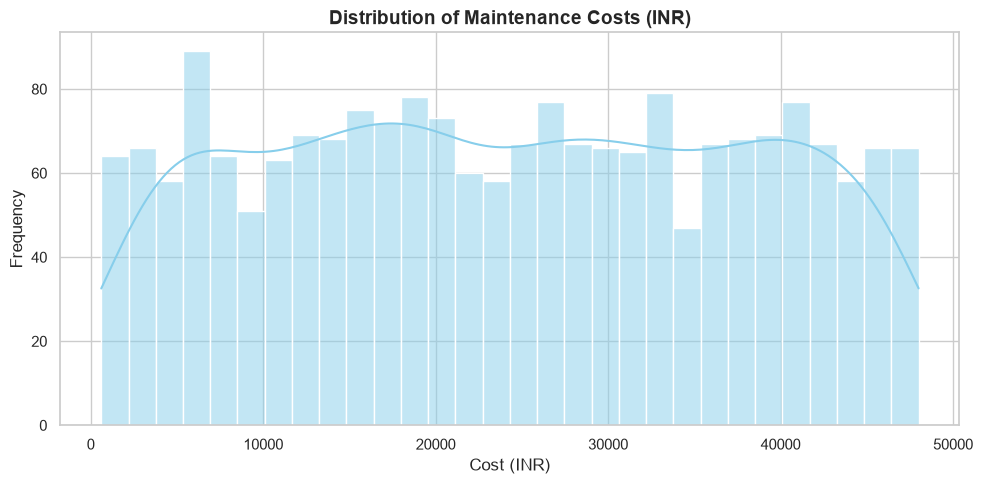

C:\Users\VIDHYA\AppData\Local\Temp\ipykernel_15808\1536184689.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='downtime_hours', y='service_type', data=df, palette='viridis')


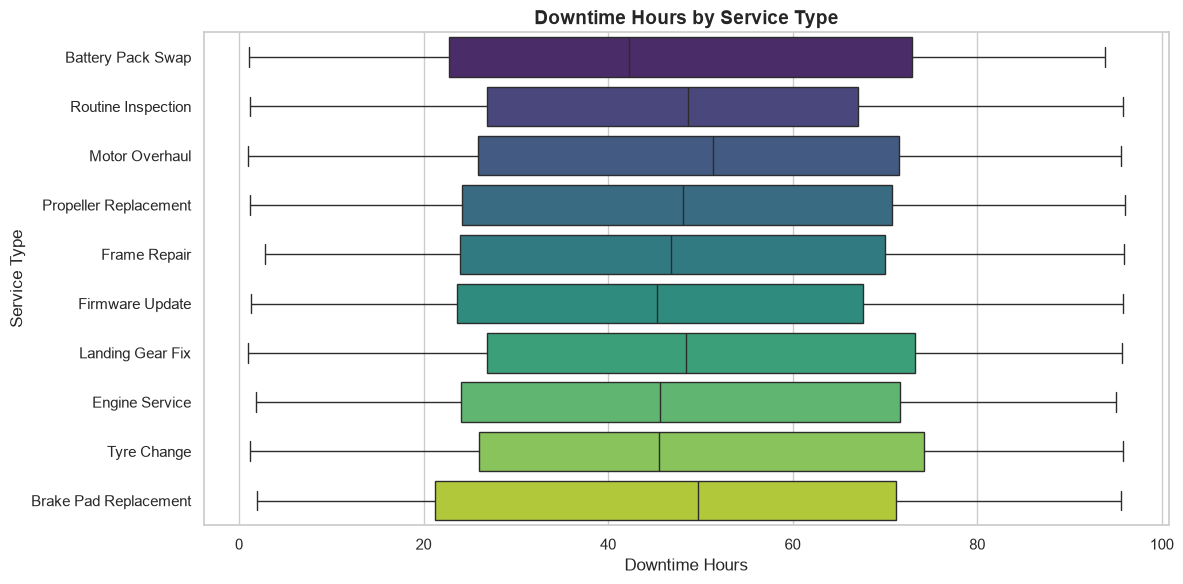

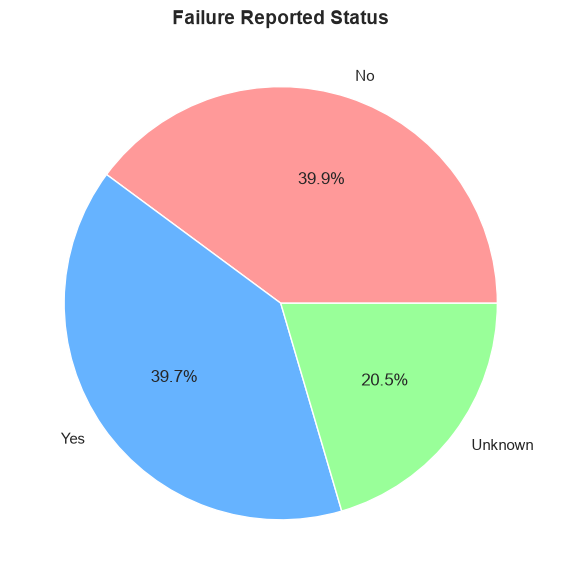

In [7]:
# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Service Costs
plt.figure(figsize=(10, 5))
sns.histplot(df['cost_inr'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Maintenance Costs (INR)', fontsize=14, fontweight='bold')
plt.xlabel('Cost (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 2. Downtime vs Service Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='downtime_hours', y='service_type', data=df, palette='viridis')
plt.title('Downtime Hours by Service Type', fontsize=14, fontweight='bold')
plt.xlabel('Downtime Hours')
plt.ylabel('Service Type')
plt.tight_layout()
plt.show()

# 3. Failure Reported Breakdown
plt.figure(figsize=(6, 6))
failure_counts = df['failure_reported'].value_counts()
plt.pie(failure_counts, labels=failure_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Failure Reported Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()